# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: Abdurrahman
- Email: Abdurrahmansy25@gmail.com
- Id Dicoding:Abdurrkhmn

## Persiapan

### Menyiapkan library yang dibutuhkan

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Mengatur tema visualisasi agar lebih profesional
sns.set_theme(style="whitegrid")
%matplotlib inline

### Menyiapkan data yang akan diguankan

In [ ]:
# Membaca dataset dengan pemisah titik koma (;)
df = pd.read_csv('data.csv', sep=';')

# Melihat 5 baris pertama untuk memahami struktur data
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [ ]:
# Cek informasi kolom dan data kosong
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

### A. Distribusi Target

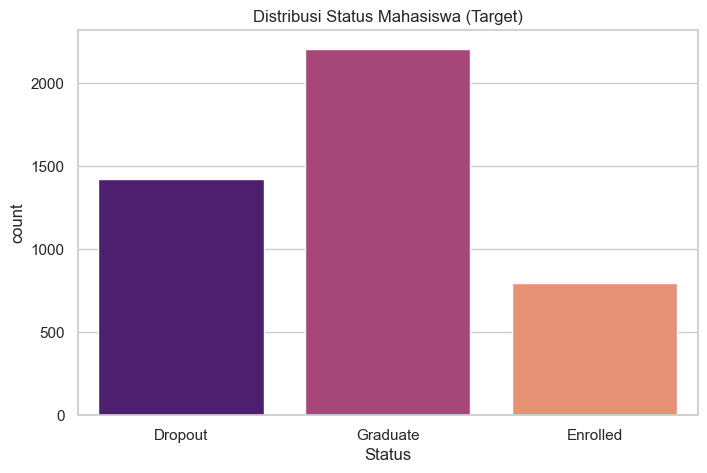

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Status', palette='magma')
plt.title('Distribusi Status Mahasiswa (Target)')
plt.show()
# Insight: Memahami perbandingan jumlah mahasiswa yang Dropout, Graduate, dan Enrolled.

### B. Faktor Beasiswa terhadap Kelulusan

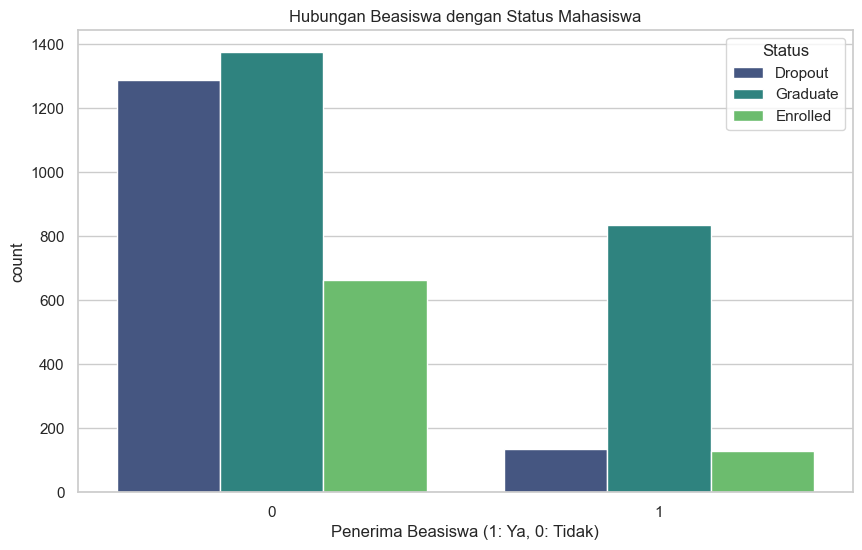

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Scholarship_holder', hue='Status', palette='viridis')
plt.title('Hubungan Beasiswa dengan Status Mahasiswa')
plt.xlabel('Penerima Beasiswa (1: Ya, 0: Tidak)')
plt.show()
# Insight: Melihat apakah dukungan finansial berpengaruh pada penurunan angka dropout.

### C. Analisis Nilai Akademik (Semester 1 & 2)

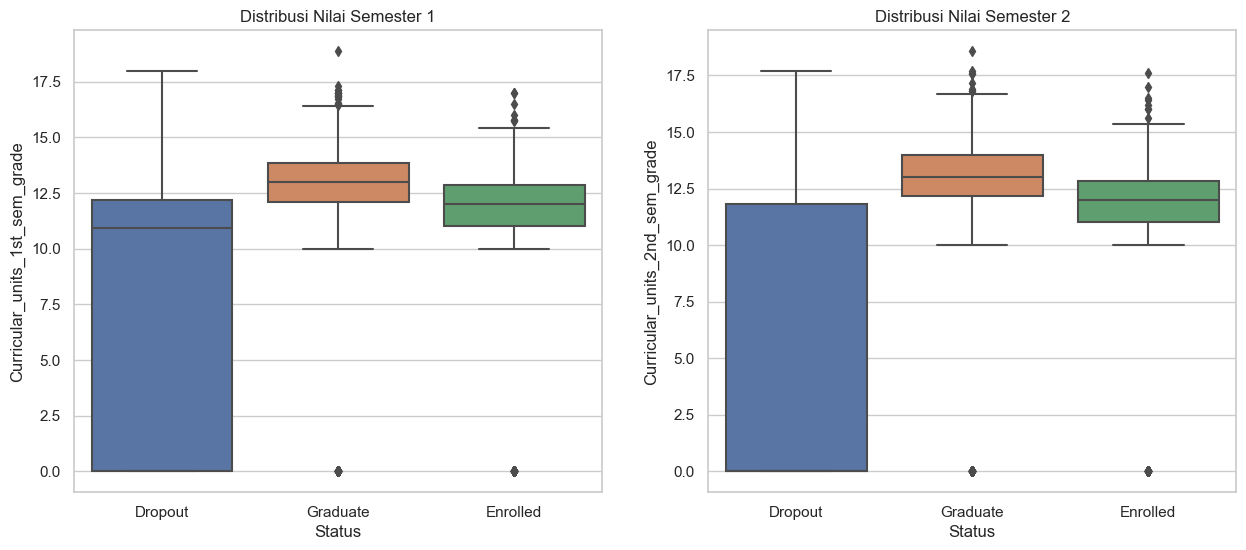

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(ax=axes[0], data=df, x='Status', y='Curricular_units_1st_sem_grade')
axes[0].set_title('Distribusi Nilai Semester 1')

sns.boxplot(ax=axes[1], data=df, x='Status', y='Curricular_units_2nd_sem_grade')
axes[1].set_title('Distribusi Nilai Semester 2')
plt.show()
# Insight: Mahasiswa yang dropout umumnya memiliki nilai yang jauh lebih rendah sejak semester awal.

## Data Preparation / Preprocessing

In [ ]:
# 1. FILTERING DATA: Hanya ambil status Graduate dan Dropout
# Kita membuang 'Enrolled' agar model fokus belajar perbedaan antara Lulus vs Putus Sekolah
df_model = df[df['Status'].isin(['Graduate', 'Dropout'])].copy()

# 2. ENCODING TARGET: Mapping menjadi Biner (0 dan 1)
# Graduate = 0, Dropout = 1
status_map = {'Graduate': 0, 'Dropout': 1}
df_model['Status'] = df_model['Status'].map(status_map)

# 3. PISAHKAN FITUR DAN TARGET
# Gunakan df_model yang sudah difilter tadi
X = df_model.drop(columns=['Status'])
y = df_model['Status']

# 4. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. LATIH ULANG MODEL (Random Forest)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 6. SIMPAN MODEL BARU
import joblib
joblib.dump(model, 'model_dropout.pkl')

print("Model berhasil dilatih ulang hanya dengan data Graduate dan Dropout.")

Model berhasil dilatih ulang hanya dengan data Graduate dan Dropout.


## Modeling

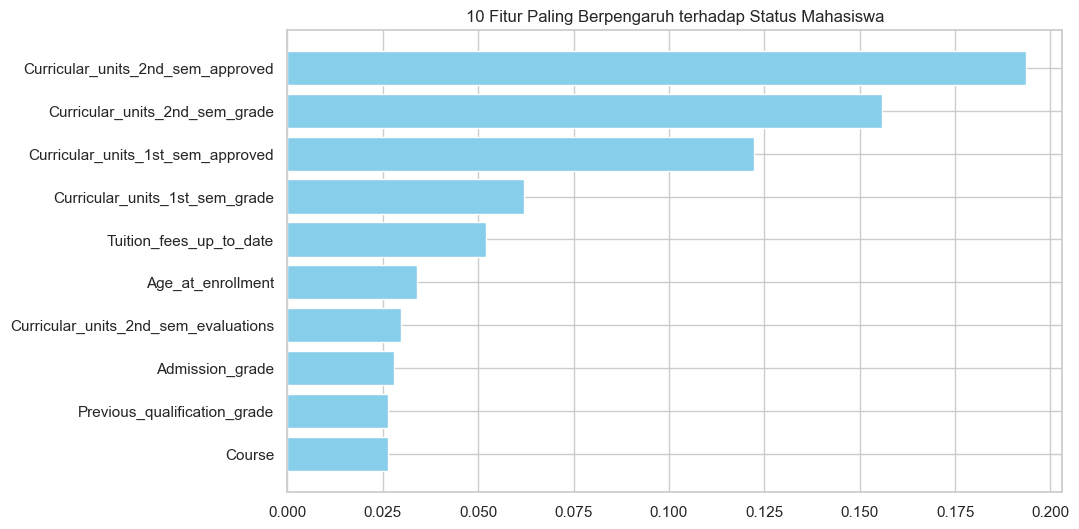

In [ ]:
# Membangun Model Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Feature Importance: Faktor apa yang paling menentukan?
importances = model.feature_importances_
top_indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(10), importances[top_indices], color='skyblue')
plt.yticks(range(10), [X.columns[i] for i in top_indices])
plt.title('10 Fitur Paling Berpengaruh terhadap Status Mahasiswa')
plt.show()

## Evaluation

Laporan Klasifikasi:
              precision    recall  f1-score   support

    Graduate       0.92      0.95      0.94       442
     Dropout       0.92      0.88      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.92       726
weighted avg       0.92      0.92      0.92       726



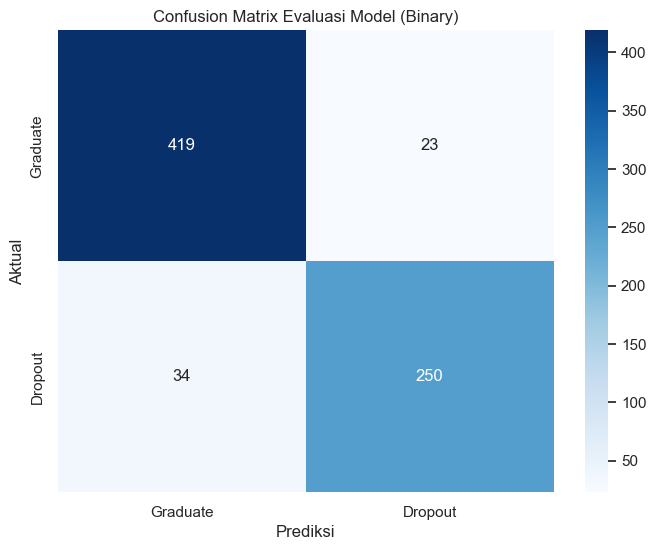

['model_dropout.pkl']

In [ ]:
# 1. Prediksi data uji
y_pred = model.predict(X_test)

# 2. Laporan Klasifikasi
# Hapus 'Enrolled' dari daftar target_names karena data Enrolled sudah tidak ada
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=['Graduate', 'Dropout']))

# 3. Confusion Matrix
plt.figure(figsize=(8, 6))
# Matriks ini sekarang akan berbentuk 2x2
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Graduate', 'Dropout'],
            yticklabels=['Graduate', 'Dropout'])

plt.title('Confusion Matrix Evaluasi Model (Binary)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# 4. Simpan Model untuk Streamlit
joblib.dump(model, 'model_dropout.pkl')